# Exploratory Data Analysis (EDA)
## ML Modeling Challenge - Wizeline

In [1]:
import polars as pl

from src.eda_functions import (
    get_histograms,
    get_mutual_information,
    get_scatter_plots,
    get_spearman_matrix,
    get_train_test_comparison,
)


# 1. Carga de datos.

In [2]:
# Datos de entrenamiento
df_train = pl.read_csv("data/training_data.csv")
print(f"Training data shape: {df_train.shape}")
df_train.head()

Training data shape: (800, 21)


feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,feature_10,feature_11,feature_12,feature_13,feature_14,feature_15,feature_16,feature_17,feature_18,feature_19,target
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
432.475954,289.373016,481.3156,358.755566,802.659004,176.761177,72.648102,720.969179,36.327684,83.768878,659.390923,4.385848,516.789458,19.624422,13.16244,42.351948,35.920392,20.755984,13.8143,384.497136,14.364922
517.59625,330.448341,585.920055,22.684031,169.81324,335.60164,284.451476,748.101047,73.701438,358.147215,11.036952,5.563334,2.960064,20.721878,17.740184,1.726915,167.576065,75.492679,2.480979,303.710869,19.984801
189.43935,553.88882,165.83379,202.465927,176.695586,321.155049,407.278389,161.245668,282.269025,221.570899,143.919562,4.536947,581.823741,101.695639,0.653592,486.859084,117.491548,6.420465,20.713314,22.651537,12.944351
237.307878,195.894881,416.752252,468.729031,611.693517,301.411711,241.880655,49.597044,122.396821,13.828319,677.161907,5.518968,45.014729,196.350455,47.638515,411.414213,67.142022,115.630943,8.927957,388.240433,14.79244
602.845256,16.103208,221.759979,345.765574,558.588369,276.704241,408.069566,19.390813,138.769765,146.662193,311.747565,2.136214,133.59043,197.634584,26.278027,111.127557,172.181136,85.869642,30.537857,625.931837,11.802634


In [3]:
# Datos de test
df_test = pl.read_csv("data/blind_test_data.csv")
print(f"Blind test data shape: {df_test.shape}")
df_test.head()

Blind test data shape: (200, 20)


feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,feature_10,feature_11,feature_12,feature_13,feature_14,feature_15,feature_16,feature_17,feature_18,feature_19
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
676.867615,32.518822,254.825875,502.26851,609.469688,497.624266,105.246239,269.045539,150.177005,312.64986,765.296227,0.237996,660.030637,147.059794,40.232132,464.424834,121.147466,68.284243,26.96987,314.461582
628.695228,426.163933,347.07028,431.106903,915.527507,301.699534,1.666992,306.733041,104.234252,63.24207,467.009734,6.608084,600.994184,43.619815,48.153926,457.256565,49.163652,85.511662,33.500538,819.537877
131.765943,323.839669,245.399775,181.814398,710.179159,59.117377,312.622788,687.965027,109.803179,381.1695,700.532108,1.82237,736.306092,138.759029,36.915389,436.174065,10.037994,62.631938,6.211169,341.361374
160.970195,489.712029,70.482159,309.486269,888.030604,412.655666,216.124989,47.415477,104.139145,326.462385,378.446187,1.686895,485.144327,143.668518,27.168148,309.715497,149.661493,66.415878,15.001753,539.087409
419.907137,216.625219,487.88786,253.704462,323.226862,65.744463,271.811469,527.726782,129.805782,168.429679,637.944633,0.948507,365.946758,72.337904,36.232169,302.772338,186.944884,106.514846,3.443809,364.341969


# 2. Pequeño vistazo a las características de las features.

In [4]:
df_train.describe()

statistic,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,feature_10,feature_11,feature_12,feature_13,feature_14,feature_15,feature_16,feature_17,feature_18,feature_19,target
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""count""",800.0,800.0,800.0,800.0,800.0,800.0,800.0,800.0,800.0,800.0,800.0,800.0,800.0,800.0,800.0,800.0,800.0,800.0,800.0,800.0,800.0
"""null_count""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""mean""",468.181612,301.960218,317.132996,283.213456,485.97595,320.953859,217.13633,387.196289,179.485453,196.003058,401.079696,3.372667,479.841915,100.112096,28.334725,277.205999,91.217615,70.927129,27.385266,457.016407,14.631342
"""std""",270.797415,170.691136,176.50192,157.698215,272.59403,185.157189,123.660691,235.131376,104.059309,111.042671,228.533579,1.986369,276.304197,59.149794,16.105155,167.38593,53.950523,40.588905,15.509062,270.650146,5.089503
"""min""",0.916648,0.800119,0.173025,0.308823,0.598527,0.997347,0.402436,0.474825,0.72785,0.264253,1.487605,0.004464,1.70624,0.194306,0.222312,1.726915,0.093789,0.072986,0.101761,0.252919,0.279805
"""25%""",240.004227,158.112763,167.572641,152.774098,250.440497,158.461761,106.935943,195.957824,94.452115,95.254095,200.565918,1.632165,250.287401,48.172929,14.692436,131.724471,44.410583,34.908806,13.81563,221.90531,10.880143
"""50%""",478.132491,303.663848,326.433636,294.986019,494.098314,328.754429,217.39164,364.208796,173.435824,200.074749,414.590211,3.351479,468.769999,100.324315,28.011475,276.142203,87.76045,74.479882,27.813702,462.790607,14.704889
"""75%""",704.493682,448.326791,474.434225,415.608904,720.679939,480.036988,327.144941,587.860394,268.758386,291.459052,613.318384,5.018215,713.208154,149.792485,42.50572,423.087972,137.821739,105.478175,40.401609,688.029902,18.220644
"""max""",940.771543,595.359858,614.271632,549.896216,950.017444,638.199832,426.308251,809.346792,367.084755,384.919108,767.311089,6.859269,979.715063,203.122292,56.467485,566.611509,187.041256,138.675389,53.25474,935.740775,27.360789


In [5]:
df_test.describe()

statistic,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,feature_10,feature_11,feature_12,feature_13,feature_14,feature_15,feature_16,feature_17,feature_18,feature_19
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""count""",200.0,200.0,200.0,200.0,200.0,200.0,200.0,200.0,200.0,200.0,200.0,200.0,200.0,200.0,200.0,200.0,200.0,200.0,200.0,200.0
"""null_count""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""mean""",479.418943,302.789598,298.881139,277.122164,487.19733,329.547672,216.553551,407.437369,185.323348,185.330621,399.885263,3.435991,484.111468,103.000612,28.38503,302.016127,88.064593,72.288016,25.734867,486.748986
"""std""",276.105184,173.501362,176.618705,159.957989,285.241709,202.975647,130.027533,232.777723,106.819818,109.137554,233.616342,2.07247,275.238131,58.42282,16.078995,167.512763,55.506339,36.787387,15.358787,275.182274
"""min""",8.902448,0.527684,0.701631,0.363441,18.294208,3.433068,1.666992,1.543639,1.277293,0.161765,0.018962,0.024754,1.558625,0.451144,0.046261,0.472701,1.772818,0.261328,0.115756,6.651236
"""25%""",253.375912,149.746565,144.360468,146.164409,229.621785,133.077516,101.450327,216.076019,102.241037,97.589719,180.502346,1.76992,252.594592,53.161282,13.734772,166.731147,36.880236,43.796466,12.134567,263.812011
"""50%""",449.93697,311.744502,276.656744,273.950954,473.80674,326.284665,206.666604,406.534414,186.766714,183.763097,423.81772,3.360177,475.580588,109.023624,28.045084,302.749651,82.884274,71.407604,25.982459,470.161969
"""75%""",700.731079,461.37891,448.222819,424.644643,735.505725,524.672633,333.626306,602.714184,276.886289,287.34351,614.226389,5.317071,719.034577,150.213729,41.433825,447.704309,135.262494,103.299932,38.771049,735.275486
"""max""",934.240319,592.806848,616.165779,549.072116,945.325628,637.718755,426.167584,806.555211,365.975352,384.098819,765.296227,6.877732,978.361203,200.31186,56.351806,566.019624,187.124657,137.775278,52.954718,935.870211


__NOTAS:__
1. Se da un breve vistazo a como los estadísticos descritivos de cada feature.
2. NO se detecta presencia de valores pérdidos.

## 3. Análisis de la correlación no paramétrica de Spearman.

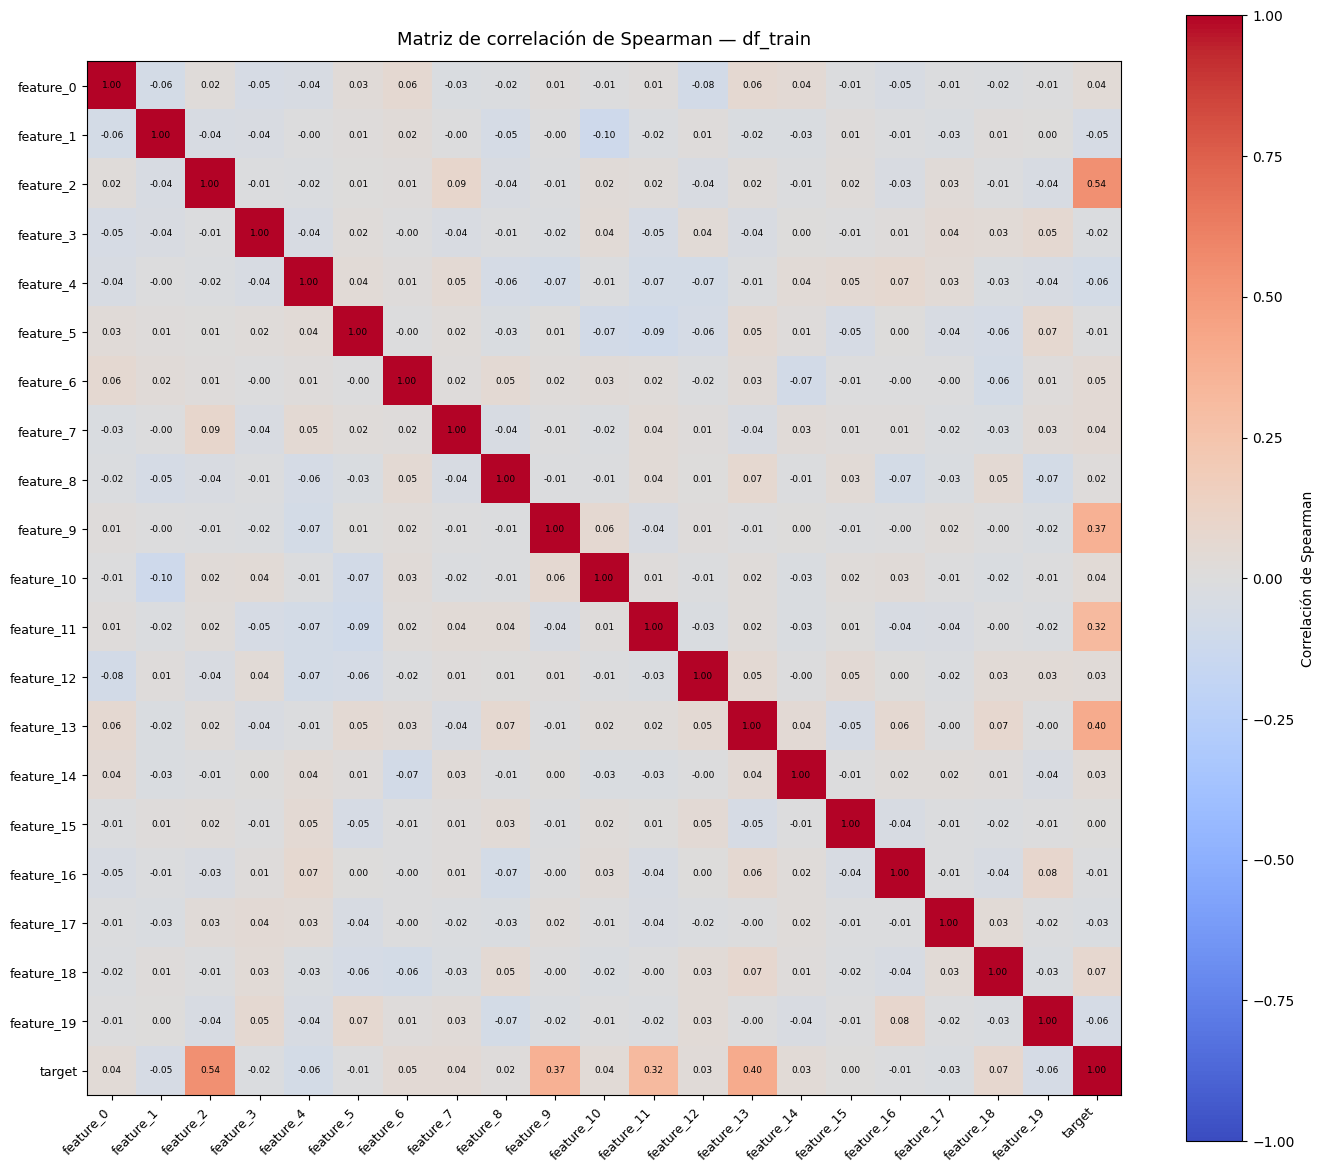

In [6]:
get_spearman_matrix(df_train)

__NOTAS:__
1. Se usa correlación no parámetrica de Spearman porque no requiere supuesto de normalidad y es mas robusta ante outliers.
2. No hay evidencia de multicolinealidad entre las features.
3. No hay evidencia de relaciones lineales fuertes entre el Target y las features (ver última fila de la matriz). Tal vez una relación lineal discreta sea entre el Target y la feature 2.
4. Tal vez la relación entre el Target y las features es más compleja y, por ende, se necesitan modelos que capturen grados de complejidad mayores a la linealidad.

## 4. Cálculo de la Información Mutua (dependencia lineal y no lineal con target) y pre-selección de features.

In [7]:
mi_df = get_mutual_information(df_train)

In [8]:
list_mi_feature_selected = mi_df.filter(pl.col("mutual_info") > 0.01).sort("mutual_info", descending=True)['feature'].to_list()
list_mi_feature_selected

['feature_2',
 'feature_13',
 'feature_16',
 'feature_9',
 'feature_3',
 'feature_18',
 'feature_11',
 'feature_5',
 'feature_1',
 'feature_12',
 'feature_15',
 'feature_4']

__NOTAS:__
1. La información mutua (MI) es una métrica que nos permite medir la dependencia (lineal o no lineal) entre dos variables, en este caso un Target y una feature. 
2. Mientras más alta sea el MI, más evidencia de dependencia.
3. La IM puede usarse para una selección de features antes de entrenamiento. 
4. La lista de variables "pre-seleccionadas" corresponde a las features con información mutua distinta de cero.

# 5. Scatter Plots de features pre-seleccionadas vs Target.

In [9]:
get_scatter_plots(df_train, features=list_mi_feature_selected)

__NOTAS:__
1. Scatter plots de las features pre-selecionadas vs el Target se han graficado para ayudar a observar las verdaderas relaciones, lineales o no lineales.
2. En cada uno de estos plots se ha dibujado la línea de tendencia no paramétrica LOWESS para reveler relaciones complejas.
3. Visualmente, se confirma la fuerte relación no lineal con el Target como, por ejemplo, sucede en features tales como la 13 y la 18.
4. Para capturar estos comportamientos, se requerirá a modelos más allá de una regresión lineal.
5. No se observa la presencia de outliers unidimensionales ni el en Target ni en las features.

## 6. Distribución de features (Histograma + Boxplot) y Target.

In [10]:
get_histograms(df_train, features=list_mi_feature_selected)

__NOTAS:__
1. Usando histograma+boxplot, se apoya visualmente a la no presencia de outliers unidimencionales en Target y features.

# 7. Comparación de distribuciones Train vs Test.


In [11]:
get_train_test_comparison(df_train, df_test, features=list_mi_feature_selected)

__NOTAS:__
1. Se comparan las distribuciones de cada feature entre el set de training (azul) y el set test (rojo) para detectar posibles diferencias o drift.
2. Si las distribuciones son similares, un buen modelo debería generalizar bien el test.

# 8. Guardado de archivos.

In [12]:
import yaml

with open("config.yaml", "r") as f:
    config = yaml.safe_load(f)

config["features"]["selected_by_mi"] = list_mi_feature_selected

with open("config.yaml", "w") as f:
    yaml.dump(config, f, allow_unicode=True, sort_keys=False)

print("Lista de features guardada en config.yaml:")
print(list_mi_feature_selected)


Lista de features guardada en config.yaml:
['feature_2', 'feature_13', 'feature_16', 'feature_9', 'feature_3', 'feature_18', 'feature_11', 'feature_5', 'feature_1', 'feature_12', 'feature_15', 'feature_4']


# 9. Conclusiones.

1. Los datos están en estado ideal para ser trabajados sin proprocesamiento previo. 
2. La estructura de dependencia  general con el target es no lineal y compleja. Por ende, considerar modelos  basados en árboles con boosting pueden ser buen comienzo para estos casos.